In [14]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [16]:
# ============================================================================
# CELL 1: LLM Query Function
# ============================================================================

import requests
import json

def get_strategy_from_llm(iteration):
    """
    Queries the local Ollama Llama3:8b model to suggest an optimization strategy.
    
    Args:
        iteration (int): The current iteration number of the algorithm.
        
    Returns:
        int: The chosen strategy number (1-5).
    """
    prompt = f"""Select strategy for knapsack optimization iteration {iteration}/100.

Phase: {"Early" if iteration < 20 else "Mid" if iteration < 60 else "Late" if iteration < 90 else "Final"}

Strategies:
1 = Balanced exploration (early phase, need diversity)
2 = Objective specialization (mid phase, extreme solutions)
3 = Gap filling (always good, improve weak objective)
4 = Aggressive exploitation (late phase, high quality only)
5 = Random perturbation (if stuck)

Reply with ONE number (1-5):"""

    url = "http://localhost:11434/api/generate"
    payload = {
        "model": "llama3:8b",
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.7,
            "max_tokens": 10
        }
    }
    
    try:
        response = requests.post(url, json=payload, timeout=40)
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            for char in response_text:
                if char.isdigit():
                    strategy = int(char)
                    return min(max(strategy, 1), 5)
            print(f"Warning: LLM response '{response_text}' did not contain a number. Defaulting to strategy 1.")
            return 1
        else:
            print(f"Error connecting to Ollama: {response.status_code} - {response.text}")
            return 1
    except requests.exceptions.RequestException as e:
        print(f"Error getting strategy from LLM: {e}. Is Ollama running?")
        return 1

# Test the function
print("Testing LLM connection...")
strategy = get_strategy_from_llm(50)
print(f"LLM suggested strategy: {strategy}")

Testing LLM connection...
LLM suggested strategy: 2


In [19]:
%%cython

# ============================================================================
# CELL 2: HYBRID LLM-MOACP - WITH ARCHITECT-GUIDED PERTURBATIONS
# ============================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# ============================================================================
# GLOBAL VARIABLES
# ============================================================================

cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# Statistics
cdef int current_iteration = 0

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

# ============================================================================
# POPULATION MANAGEMENT
# ============================================================================

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

# ============================================================================
# PARETO DOMINANCE
# ============================================================================

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

# ============================================================================
# EPSILON INDICATOR & FITNESS
# ============================================================================

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# ============================================================================
# FILE I/O
# ============================================================================

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

# ============================================================================
# INITIALIZATION & EVALUATION
# ============================================================================

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

# ============================================================================
# ARCHIVE MANAGEMENT
# ============================================================================

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

# ============================================================================
# SELECTION
# ============================================================================

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# ============================================================================
# HELPER TO GET PARETO FRONT STATS
# ============================================================================

cdef dict get_pareto_front_stats(pop *archive):
    """Calculates min/max statistics from the Pareto front archive."""
    cdef dict stats = {
        'min_f1': 1e9, 'max_f1': -1e9,
        'min_f2': 1e9, 'max_f2': -1e9
    }
    cdef int i
    if archive.size > 0:
        for i in range(archive.size):
            s = archive.ind_array[i]
            if s.f[0] < stats['min_f1']: stats['min_f1'] = s.f[0]
            if s.f[0] > stats['max_f1']: stats['max_f1'] = s.f[0]
            if s.f[1] < stats['min_f2']: stats['min_f2'] = s.f[1]
            if s.f[1] > stats['max_f2']: stats['max_f2'] = s.f[1]
    return stats

# ============================================================================
# HYBRID LOCAL SEARCH - WITH ARCHITECT-GUIDED PERTURBATIONS
# ============================================================================

cdef void Indicator_local_search1_hybrid(pop *SP, pop *Sarchive, int size, dict strategy_dict, object strategy_provider):
    """
    Hybrid local search. Executes different perturbation types chosen by the LLM.
    """
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, l, sol, mino, consistant, taille, feasible, tv
    cdef int convergence, tmp_pris, tmp_nonpris
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef list selected_items
    cdef int strategy_code
    cdef int k, item_to_remove, item_to_add
    cdef double best_gain, current_gain
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    strategy_code = strategy_dict.get('code', 0)
    
    # *** NEW: ARCHITECT-GUIDED PERTURBATION LOGIC ***
    if strategy_code == -1:
        print("[CYTHON] Applying ARCHITECT-guided perturbation...")
        perturbation_type = strategy_dict.get('perturbation_type', 1)
        memory_set = strategy_dict.get('memory', set())
        x = SP.ind_array[0]

        if perturbation_type == 1: # LARGE_RANDOM
            # This is the baseline's powerful perturbation
            selected_items = []
            attempts = 0
            while len(selected_items) < 5 and attempts < 5 * 10:
                maxp = irand(ni)
                attempts += 1
                if x.Items[maxp] == 0 and maxp not in selected_items:
                    consistant = 1
                    for r in range(nf):
                        if x.capa[r] + weights[r][maxp] > capacities[r]:
                            consistant = 0
                            break
                    if consistant == 1:
                        selected_items.append(maxp)
            # Remove one random item to make space
            while True:
                mino = irand(ni)
                if x.Items[mino] == 1: break
            x.Items[mino] = 0
            # Add the new items
            for item in selected_items:
                x.Items[item] = 1
            print(f"[CYTHON] Executed LARGE_RANDOM perturbation.")

        elif perturbation_type == 2: # BALANCED_SWAP
            # Find the weaker objective
            weaker_obj = 0 if x.f[0] < x.f[1] else 1
            # Find best 2-2 swap for the weaker objective
            best_gain = -1e9
            item_to_remove = -1
            item_to_add = -1
            for i in range(ni):
                if x.Items[i] == 1:
                    for j in range(ni):
                        if x.Items[j] == 0:
                            if (i, j) in memory_set: continue
                            feasible = 1
                            for k in range(nf):
                                if x.capa[k] - weights[k][i] + weights[k][j] > capacities[k]:
                                    feasible = 0
                                    break
                            if feasible:
                                current_gain = profits[weaker_obj][j] - profits[weaker_obj][i]
                                if current_gain > best_gain:
                                    best_gain = current_gain
                                    item_to_remove = i
                                    item_to_add = j
            # Perform the swap if found
            if item_to_remove != -1:
                x.Items[item_to_remove] = 0
                x.Items[item_to_add] = 1
                memory_set.add((item_to_remove, item_to_add))
                print(f"[CYTHON] Executed BALANCED_SWAP for Obj{weaker_obj+1}.")

        elif perturbation_type == 3: # DIVERSITY_JUMP
            # This is a simplified version of a diversity jump.
            # A full implementation would require tracking item frequencies in the archive.
            # For now, we'll perform a single random swap to encourage exploration.
            while True:
                mino = irand(ni)
                if x.Items[mino] == 1: break
            while True:
                maxp = irand(ni)
                if x.Items[maxp] == 0 and maxp != mino: break
            x.Items[mino] = 0
            x.Items[maxp] = 1
            print(f"[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).")

        ##

        elif perturbation_type == 4: # LLM_GUIDED_ADD
            print("[CYTHON] Applying LLM-guided solution generation...")
            
            # 1. Prepare data for the LLM
            current_items = {i for i in range(ni) if x.Items[i] == 1}
            remaining_capa = [capacities[i] - x.capa[i] for i in range(nf)]
            
            # Create simplified dicts for the LLM (e.g., for 2 objectives)
            profits_dict = {i: (profits[0][i], profits[1][i]) for i in range(ni) if x.Items[i] == 0}
            weights_dict = {i: (weights[0][i], weights[1][i]) for i in range(ni) if x.Items[i] == 0}

            # 2. Call the Python function to get item suggestions
            suggested_items = strategy_provider._get_items_from_llm(
                current_items, remaining_capa, profits_dict, weights_dict, L
            )
            
            # 3. Remove one random item to make space (as per your preference)
            while True:
                mino = irand(ni)
                if x.Items[mino] == 1: 
                    break
            x.Items[mino] = 0
            x.nombr -= 1
            for r in range(nf):
                x.capa[r] -= weights[r][mino]
                x.f[r] -= profits[r][mino]

            # 4. Add the LLM-suggested items if they are valid
            for item_idx in suggested_items:
                if 0 <= item_idx < ni and x.Items[item_idx] == 0:
                    feasible = 1
                    for r in range(nf):
                        if x.capa[r] + weights[r][item_idx] > capacities[r]:
                            feasible = 0
                            break
                    if feasible:
                        x.Items[item_idx] = 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][item_idx]
                            x.f[r] += profits[r][item_idx]
            print(f"[CYTHON] Executed LLM_GUIDED_ADD, suggested {len(suggested_items)} items.")


    # OUTER WHILE LOOP (Standard Search)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    # 1. Remove one item
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    
                    # 2. Select items to add using the ORIGINAL RANDOM SEARCH
                    selected_items = []
                    attempts = 0
                    while len(selected_items) < L and attempts < L * 10:
                        maxp = irand(ni)
                        attempts += 1
                        if x.Items[maxp] == 0 and maxp != mino and maxp not in selected_items:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant == 1:
                                selected_items.append(maxp)
                    
                    # 3. Add selected items
                    taille = 0
                    for item in selected_items:
                        if x.Items[item] == 0 and item != mino:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][item] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant == 1:
                                feasible = 1
                                for r in range(taille):
                                    if item == remplace[r]:
                                        feasible = 0
                                        break
                                if feasible == 1:
                                    remplace[taille] = item
                                    taille += 1
                                    x.Items[item] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][item]
                                        x.f[r] += profits[r][item]
                    
                    # 4. Evaluate
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    # 5. Accept or reject
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        # Restore
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    free(remplace)

# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_hybrid_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, strategy_provider):
    """
    Run Hybrid LLM-MOACP with intelligent perturbation.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    global current_iteration

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    STAGNATION_THRESHOLD = 20

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"\n========== RUN {run}/{NRUNS} ==========")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        strategy_provider.reset_for_run(run)

        it = 0
        while it < NBL:
            current_iteration = it
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Get Pareto front stats for the ARCHITECT LLM
            pareto_stats = get_pareto_front_stats(P)
            
            # Get strategy from Python provider, passing all context
            current_strategy = strategy_provider.get_strategy(current_iteration, P.size, pareto_stats)            
            # Call hybrid local search with the determined strategy
            Indicator_local_search1_hybrid(solutions, archive, alpha, current_strategy, strategy_provider)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

In [24]:
# ============================================================================
# CELL 2: PYTHON STRATEGY PROVIDER AND BASIC FUNCTIONS
# ============================================================================

import requests
import json
import matplotlib.pyplot as plt
import time
import math

# ============================================================================
# THE ARCHITECT LLM PROVIDER
# ============================================================================

class LLMStrategyProvider:
    """
    The Architect LLM provider. Chooses between different
    powerful perturbation types to guide the search.
    """
    def __init__(self, model_name="llama3:8b", stagnation_threshold=20, nbitems=250):
        self.model_name = model_name
        self.stagnation_threshold = stagnation_threshold
        self.url = "http://localhost:11434/api/generate"
        self.ni = nbitems
        self.stagnation_counter = 0
        self.last_archive_size = 0
        self.llm_call_count = 0
        self.recent_swaps = set()
        print(f"[PROVIDER] Initialized ARCHITECT model '{model_name}'")
        print(f"[PROVIDER] Stagnation threshold: {stagnation_threshold}, Items: {nbitems}")

    def reset_for_run(self, run_id):
        """Reset state for a new run."""
        self.stagnation_counter = 0
        self.last_archive_size = 0
        self.recent_swaps.clear()
        print(f"[PROVIDER] --- Architect Reset for Run {run_id} ---")

    def _query_llm_for_architecture(self, front_stats):
        """Queries the LLM to choose a high-level perturbation type."""
        prompt = f"""You are an expert architect for multi-objective optimization.
The search is stuck. Here is the current state of the Pareto front:
- Objective 1 range: {front_stats['min_f1']:.2f} to {front_stats['max_f1']:.2f}
- Objective 2 range: {front_stats['min_f2']:.2f} to {front_stats['max_f2']:.2f}

Which perturbation type is best to improve the front's diversity and quality?
1. LARGE_RANDOM: A big, chaotic jump (remove 1, add 5 random). Good for exploration.
2. BALANCED_SWAP: A focused jump (remove 2 weak, add 2 strong). Good for filling gaps.
3. DIVERSITY_JUMP: A creative jump (remove most common, add 1 random). Good for escaping crowded areas.
4. LLM_GUIDED_ADD: An intelligent jump (remove 1, add items suggested by an expert LLM). Best for targeted improvement.

Choose the best type and reply with only the number (1, 2, 3, or 4)."""

        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.7, "max_tokens": 10}
        }
        try:
            response = requests.post(self.url, json=payload, timeout=40)
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()
                for char in response_text:
                    if char.isdigit():
                        choice = int(char)
                        if 1 <= choice <= 4:
                            return choice
                print(f"[PROVIDER] LLM Warning: Could not parse choice. Defaulting to 1.")
                return 1
            else:
                print(f"[PROVIDER] LLM Error: HTTP {response.status_code}")
                return 1
        except requests.exceptions.RequestException as e:
            print(f"[PROVIDER] LLM Connection Error: {e}. Defaulting to 1.")
            return 1
    
    def _get_items_from_llm(self, current_solution_items, remaining_capacity, profits_dict, weights_dict, num_items_to_suggest=5):
        """
        Queries the LLM to suggest specific items to add to the current solution.
        """
        item_details = []
        for i in sorted(profits_dict.keys())[:100]:
            if i not in current_solution_items:
                item_details.append(f"Item {i}: weight={weights_dict[i]}, profit={profits_dict[i]}")
    
        prompt = f"""You are an expert assistant for a multi-objective knapsack problem.
I need to add exactly {num_items_to_suggest} items to my current knapsack solution.

Current state:
- Items already selected: {len(current_solution_items)} items
- Remaining capacity: {remaining_capacity}

Here are some available items not yet selected:
{chr(10).join(item_details[:50])}

Your task:
1. Analyze the available items.
2. Select {num_items_to_suggest} items that provide the best profit-to-weight ratio and fit within the remaining capacity.
3. Your goal is to maximize the objective values.

Reply with ONLY a JSON list of the chosen item indices.
Example: [123, 45, 67, 89, 10]
"""
    
        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.2, "max_tokens": 50}
        }
        try:
            response = requests.post(self.url, json=payload, timeout=40)
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()
                suggested_items = json.loads(response_text)
                if isinstance(suggested_items, list):
                    self.llm_call_count += 1
                    print(f"[PROVIDER] LLM suggested items: {suggested_items[:5]}")
                    return suggested_items
                else:
                    print(f"[PROVIDER] LLM Warning: Response was not a list. Defaulting to empty.")
                    return []
            else:
                print(f"[PROVIDER] LLM Error: HTTP {response.status_code}")
                return []
        except (requests.exceptions.RequestException, json.JSONDecodeError) as e:
            print(f"[PROVIDER] LLM Error during item generation: {e}.")
            return []

    def get_strategy(self, iteration, archive_size, pareto_stats):
        """Main method. Returns strategy 0 (default) or an architect-guided suggestion."""
        if archive_size > self.last_archive_size:
            self.stagnation_counter = 0
            self.last_archive_size = archive_size
        else:
            self.stagnation_counter += 1
        
        if self.stagnation_counter < self.stagnation_threshold:
            return {'code': 0, 'reason': 'Default: Original Random Search'}

        print(f"\n[PROVIDER] *** STAGNATION DETECTED ***")
        print(f"[PROVIDER] Iteration: {iteration}, Archive Size: {archive_size}")
        print(f"[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [{pareto_stats['min_f1']:.0f}, {pareto_stats['max_f1']:.0f}], Obj2: [{pareto_stats['min_f2']:.0f}, {pareto_stats['max_f2']:.0f}]")
        
        perturbation_type = self._query_llm_for_architecture(pareto_stats)
        self.llm_call_count += 1

        perturbation_names = {1: "LARGE_RANDOM", 2: "BALANCED_SWAP", 3: "DIVERSITY_JUMP", 4: "LLM_GUIDED_ADD"}
        perturbation_name = perturbation_names.get(perturbation_type, "LARGE_RANDOM")
        print(f"[PROVIDER] LLM suggested perturbation: {perturbation_name}")
        self.stagnation_counter = 0
        return {
            'code': -1,
            'reason': f'Architect LLM-guided perturbation: {perturbation_name}',
            'perturbation_type': perturbation_type,
            'memory': self.recent_swaps
        }

# ============================================================================
# BASIC UTILITY FUNCTIONS
# ============================================================================

def dominates(a, b):
    """Returns True if a dominates b (maximization)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract Pareto-optimal points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def load_points(filename):
    """Load points from result file."""
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    return points

def plot_pareto_front(filename, title_suffix=""):
    """Plot a single Pareto front."""
    points = load_points(filename)
    if not points:
        print(f"No data to plot in {filename}")
        return
    pareto = get_true_pareto_front(points)
    if not pareto:
        print(f"No Pareto front found in {filename}")
        return
    xs, ys = zip(*pareto)
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, color='purple', label=f"Pareto front {title_suffix}")
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"Pareto Front from {filename}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def report_pareto_stats(filename):
    """Report basic statistics."""
    points = load_points(filename)
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)
    print(f"\n--- Results for {filename} ---")
    print(f"  Total points generated: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")
    return total_points, num_pareto

print("✅ Cell 2 loaded: LLMStrategyProvider and basic functions ready!")

✅ Cell 2 loaded: LLMStrategyProvider and basic functions ready!


In [25]:
# ============================================================================
# CELL 3: COMPREHENSIVE METRICS AND COMPARISON FUNCTIONS
# ============================================================================

import numpy as np

# ============================================================================
# HYPERVOLUME CALCULATION (2D Maximization)
# ============================================================================

def calculate_hypervolume_2d(pareto_front, reference_point):
    """Calculate hypervolume for 2D maximization problem."""
    if not pareto_front:
        return 0.0
    
    sorted_front = sorted(pareto_front, key=lambda x: x[0], reverse=True)
    hypervolume = 0.0
    prev_y = reference_point[1]
    
    for point in sorted_front:
        width = point[0] - reference_point[0]
        height = point[1] - prev_y
        if width > 0 and height > 0:
            hypervolume += width * height
        prev_y = point[1]
    
    return hypervolume

def get_reference_point(all_points, offset=0.1):
    """Calculate reference point for hypervolume."""
    if not all_points:
        return [0, 0]
    
    all_points = np.array(all_points)
    min_vals = np.min(all_points, axis=0)
    range_vals = np.max(all_points, axis=0) - min_vals
    ref_point = min_vals - offset * range_vals
    return ref_point.tolist()

# ============================================================================
# DIVERSITY METRICS
# ============================================================================

def calculate_spacing(pareto_front):
    """Calculate spacing metric (lower is better)."""
    if len(pareto_front) < 2:
        return 0.0
    
    distances = []
    for i, point_i in enumerate(pareto_front):
        min_dist = float('inf')
        for j, point_j in enumerate(pareto_front):
            if i != j:
                dist = sum((a - b) ** 2 for a, b in zip(point_i, point_j)) ** 0.5
                if dist < min_dist:
                    min_dist = dist
        distances.append(min_dist)
    
    mean_dist = np.mean(distances)
    spacing = np.sqrt(sum((d - mean_dist) ** 2 for d in distances) / len(distances))
    return spacing

def calculate_spread(pareto_front):
    """Calculate spread metric (diversity)."""
    if len(pareto_front) < 2:
        return 0.0
    
    pareto_array = np.array(pareto_front)
    ranges = np.max(pareto_array, axis=0) - np.min(pareto_array, axis=0)
    spread = np.sum(ranges)
    return spread

def calculate_diversity_score(pareto_front):
    """Calculate combined diversity score."""
    spacing = calculate_spacing(pareto_front)
    spread = calculate_spread(pareto_front)
    
    if spacing > 0:
        diversity_score = spread / (spacing + 1e-10)
    else:
        diversity_score = spread
    
    return diversity_score

# ============================================================================
# DOMINATION METRICS
# ============================================================================

def calculate_domination_count(front_a, front_b):
    """Count how many solutions in front_a dominate solutions in front_b."""
    dominated_count = 0
    
    for sol_b in front_b:
        for sol_a in front_a:
            if dominates(sol_a, sol_b):
                dominated_count += 1
                break
    
    domination_percentage = (dominated_count / len(front_b)) * 100 if front_b else 0
    return dominated_count, domination_percentage

def calculate_mutual_dominance(front_a, front_b):
    """Calculate mutual dominance between two fronts."""
    a_dominates_b, a_dom_pct = calculate_domination_count(front_a, front_b)
    b_dominates_a, b_dom_pct = calculate_domination_count(front_b, front_a)
    
    return {
        'A_dominates_B': a_dominates_b,
        'A_dominates_B_pct': a_dom_pct,
        'B_dominates_A': b_dominates_a,
        'B_dominates_A_pct': b_dom_pct,
        'net_advantage': a_dominates_b - b_dominates_a
    }

def calculate_non_dominated_ratio(front_a, front_b):
    """Calculate percentage of solutions in A that are non-dominated by any in B."""
    non_dominated_count = 0
    
    for sol_a in front_a:
        dominated = False
        for sol_b in front_b:
            if dominates(sol_b, sol_a):
                dominated = True
                break
        if not dominated:
            non_dominated_count += 1
    
    ratio = (non_dominated_count / len(front_a)) * 100 if front_a else 0
    return non_dominated_count, ratio

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================

def comprehensive_comparison(baseline_file, llm_file, title=""):
    """Perform comprehensive comparison between baseline and LLM results."""
    print("\n" + "="*80)
    print(f"COMPREHENSIVE COMPARISON: {title}")
    print("="*80)
    
    baseline_points = load_points(baseline_file)
    llm_points = load_points(llm_file)
    baseline_pareto = get_true_pareto_front(baseline_points)
    llm_pareto = get_true_pareto_front(llm_points)
    
    print(f"\n📊 Basic Statistics:")
    print(f"  Baseline - Total: {len(baseline_points)}, Pareto: {len(baseline_pareto)}")
    print(f"  LLM      - Total: {len(llm_points)}, Pareto: {len(llm_pareto)}")
    print(f"  Pareto Size Improvement: {len(llm_pareto) - len(baseline_pareto):+d} " +
          f"({((len(llm_pareto)/len(baseline_pareto) - 1) * 100):+.1f}%)")
    
    # Get common reference point
    all_combined = baseline_points + llm_points
    ref_point = get_reference_point(all_combined, offset=0.1)
    print(f"\n📍 Reference Point: {ref_point}")
    
    # HYPERVOLUME
    print(f"\n🔷 HYPERVOLUME (Higher is Better):")
    baseline_hv = calculate_hypervolume_2d(baseline_pareto, ref_point)
    llm_hv = calculate_hypervolume_2d(llm_pareto, ref_point)
    hv_improvement = ((llm_hv / baseline_hv - 1) * 100) if baseline_hv > 0 else 0
    
    print(f"  Baseline HV: {baseline_hv:,.2f}")
    print(f"  LLM HV:      {llm_hv:,.2f}")
    print(f"  Improvement: {hv_improvement:+.2f}%")
    
    if llm_hv > baseline_hv:
        print(f"  ✅ LLM WINS on Hypervolume!")
    elif llm_hv < baseline_hv:
        print(f"  ⚠️  Baseline WINS on Hypervolume")
    else:
        print(f"  🤝 TIE on Hypervolume")
    
    # DIVERSITY
    print(f"\n🌈 DIVERSITY METRICS:")
    
    baseline_spacing = calculate_spacing(baseline_pareto)
    llm_spacing = calculate_spacing(llm_pareto)
    spacing_improvement = ((baseline_spacing / llm_spacing - 1) * 100) if llm_spacing > 0 else 0
    
    print(f"  Spacing (Lower is Better):")
    print(f"    Baseline: {baseline_spacing:.4f}")
    print(f"    LLM:      {llm_spacing:.4f}")
    print(f"    Improvement: {spacing_improvement:+.2f}%")
    
    baseline_spread = calculate_spread(baseline_pareto)
    llm_spread = calculate_spread(llm_pareto)
    spread_improvement = ((llm_spread / baseline_spread - 1) * 100) if baseline_spread > 0 else 0
    
    print(f"\n  Spread (Higher is Better):")
    print(f"    Baseline: {baseline_spread:.2f}")
    print(f"    LLM:      {llm_spread:.2f}")
    print(f"    Improvement: {spread_improvement:+.2f}%")
    
    baseline_diversity = calculate_diversity_score(baseline_pareto)
    llm_diversity = calculate_diversity_score(llm_pareto)
    diversity_improvement = ((llm_diversity / baseline_diversity - 1) * 100) if baseline_diversity > 0 else 0
    
    print(f"\n  Combined Diversity Score (Higher is Better):")
    print(f"    Baseline: {baseline_diversity:.2f}")
    print(f"    LLM:      {llm_diversity:.2f}")
    print(f"    Improvement: {diversity_improvement:+.2f}%")
    
    if llm_diversity > baseline_diversity:
        print(f"  ✅ LLM WINS on Diversity!")
    else:
        print(f"  ⚠️  Baseline WINS on Diversity")
    
    # DOMINATION
    print(f"\n⚔️  DOMINATION ANALYSIS:")
    
    mutual = calculate_mutual_dominance(llm_pareto, baseline_pareto)
    print(f"  LLM dominates Baseline: {mutual['A_dominates_B']} solutions ({mutual['A_dominates_B_pct']:.1f}%)")
    print(f"  Baseline dominates LLM: {mutual['B_dominates_A']} solutions ({mutual['B_dominates_A_pct']:.1f}%)")
    print(f"  Net Advantage (LLM): {mutual['net_advantage']:+d} solutions")
    
    llm_non_dom_count, llm_non_dom_pct = calculate_non_dominated_ratio(llm_pareto, baseline_pareto)
    baseline_non_dom_count, baseline_non_dom_pct = calculate_non_dominated_ratio(baseline_pareto, llm_pareto)
    
    print(f"\n  Non-dominated by opponent:")
    print(f"    LLM solutions not dominated by Baseline: {llm_non_dom_count} ({llm_non_dom_pct:.1f}%)")
    print(f"    Baseline solutions not dominated by LLM: {baseline_non_dom_count} ({baseline_non_dom_pct:.1f}%)")
    
    if mutual['net_advantage'] > 0:
        print(f"  ✅ LLM WINS on Domination!")
    elif mutual['net_advantage'] < 0:
        print(f"  ⚠️  Baseline WINS on Domination")
    else:
        print(f"  🤝 TIE on Domination")
    
    # SUMMARY
    print(f"\n📋 OVERALL SUMMARY:")
    wins = {'LLM': 0, 'Baseline': 0, 'Tie': 0}
    
    if llm_hv > baseline_hv:
        wins['LLM'] += 1
    elif llm_hv < baseline_hv:
        wins['Baseline'] += 1
    else:
        wins['Tie'] += 1
    
    if llm_diversity > baseline_diversity:
        wins['LLM'] += 1
    elif llm_diversity < baseline_diversity:
        wins['Baseline'] += 1
    else:
        wins['Tie'] += 1
    
    if mutual['net_advantage'] > 0:
        wins['LLM'] += 1
    elif mutual['net_advantage'] < 0:
        wins['Baseline'] += 1
    else:
        wins['Tie'] += 1
    
    print(f"  LLM Wins: {wins['LLM']}/3 metrics")
    print(f"  Baseline Wins: {wins['Baseline']}/3 metrics")
    print(f"  Ties: {wins['Tie']}/3 metrics")
    
    if wins['LLM'] > wins['Baseline']:
        print(f"\n  🏆 OVERALL WINNER: LLM-Enhanced Approach!")
    elif wins['Baseline'] > wins['LLM']:
        print(f"\n  🏆 OVERALL WINNER: Baseline Approach")
    else:
        print(f"\n  🤝 OVERALL: Tie")
    
    print("="*80)
    
    return {
        'baseline_hv': baseline_hv,
        'llm_hv': llm_hv,
        'hv_improvement': hv_improvement,
        'baseline_diversity': baseline_diversity,
        'llm_diversity': llm_diversity,
        'diversity_improvement': diversity_improvement,
        'domination': mutual,
        'wins': wins
    }

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison(baseline_file, llm_file, title=""):
    """Plot both Pareto fronts for comparison."""
    baseline_points = load_points(baseline_file)
    llm_points = load_points(llm_file)
    
    baseline_pareto = get_true_pareto_front(baseline_points)
    llm_pareto = get_true_pareto_front(llm_points)
    
    if not baseline_pareto or not llm_pareto:
        print(f"No data to plot for {title}")
        return
    
    baseline_x, baseline_y = zip(*baseline_pareto)
    llm_x, llm_y = zip(*llm_pareto)
    
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Overlay
    plt.subplot(1, 2, 1)
    plt.scatter(baseline_x, baseline_y, color='blue', alpha=0.6, s=50, label='Baseline', marker='o')
    plt.scatter(llm_x, llm_y, color='red', alpha=0.6, s=50, label='LLM-Enhanced', marker='^')
    plt.xlabel("Objective 1", fontsize=12)
    plt.ylabel("Objective 2", fontsize=12)
    plt.title(f"Pareto Front Comparison\n{title}", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Side by side
    plt.subplot(1, 2, 2)
    plt.scatter(baseline_x, baseline_y, color='blue', alpha=0.8, s=60, label=f'Baseline (n={len(baseline_pareto)})')
    plt.scatter(llm_x, llm_y, color='red', alpha=0.8, s=60, label=f'LLM (n={len(llm_pareto)})', marker='^')
    plt.xlabel("Objective 1", fontsize=12)
    plt.ylabel("Objective 2", fontsize=12)
    plt.title("Pareto Fronts Detail", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def run_full_comparison(instance_name, baseline_file, llm_file):
    """Run full comparison suite for an instance."""
    print(f"\n{'#'*80}")
    print(f"# ANALYZING: {instance_name}")
    print(f"{'#'*80}")
    
    results = comprehensive_comparison(baseline_file, llm_file, title=instance_name)
    plot_comparison(baseline_file, llm_file, title=instance_name)
    
    return results

print("✅ Cell 3 loaded: Comprehensive metrics ready!")

✅ Cell 3 loaded: Comprehensive metrics ready!


EXECUTING HYBRID LLM-MOACP FOR ALL 2-OBJECTIVE INSTANCES

Processing: 250.2.txt
[PROVIDER] Initialized ARCHITECT model 'llama3:8b'
[PROVIDER] Stagnation threshold: 10, Items: 250

========== RUN 1/10 ==========
Instance: 250.2.txt, Items: 250, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 73, Archive Size: 125
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [7972, 9793], Obj2: [8056, 10010]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 83, Archive Size: 124
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [7972, 9793], Obj2: [8056, 10010]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

[PROVIDER] *** STAGNATION DETECTED ***
[

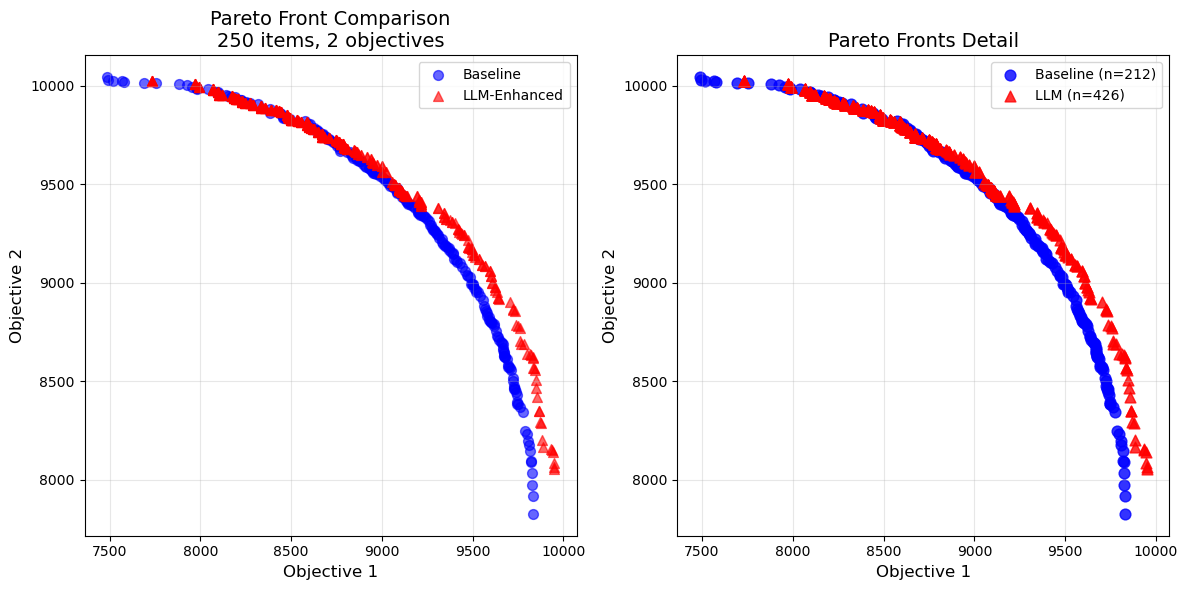


Processing: 500.2.txt
[PROVIDER] Initialized ARCHITECT model 'llama3:8b'
[PROVIDER] Stagnation threshold: 10, Items: 500

========== RUN 1/10 ==========
Instance: 500.2.txt, Items: 500, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 90, Archive Size: 273
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [16262, 19990], Obj2: [16927, 20425]
[PROVIDER] LLM suggested perturbation: BALANCED_SWAP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed BALANCED_SWAP for Obj2.

========== RUN 2/10 ==========
Instance: 500.2.txt, Items: 500, Objectives: 2
[PROVIDER] --- Architect Reset for Run 2 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 61, Archive Size: 241
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [16059, 19979], Obj2: [16857, 20397]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (

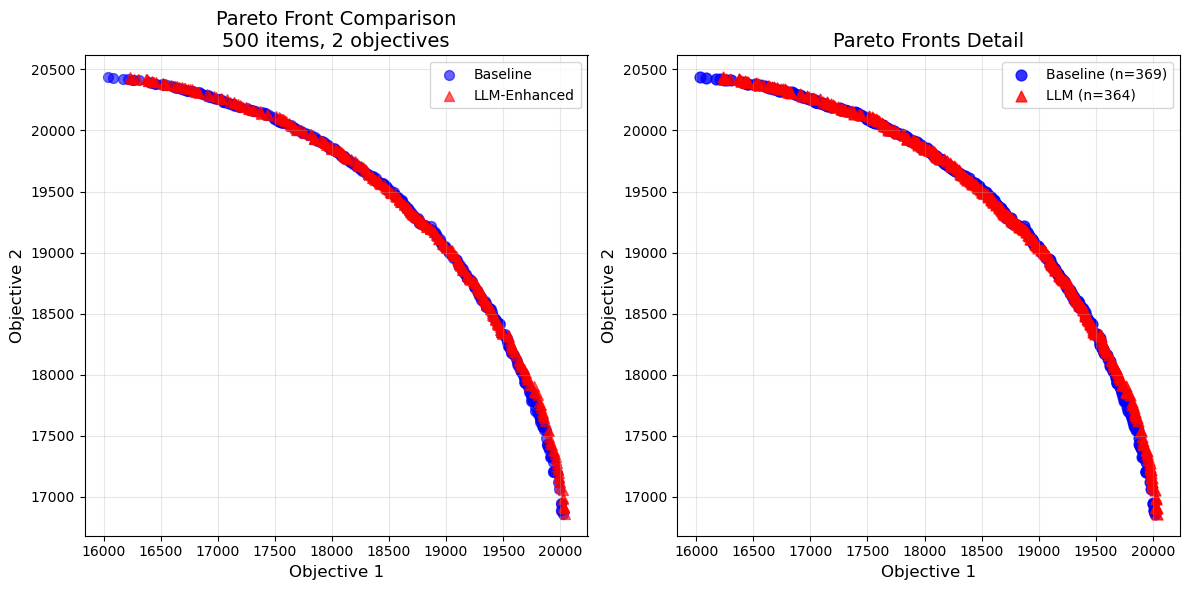


Processing: 750.2.txt
[PROVIDER] Initialized ARCHITECT model 'llama3:8b'
[PROVIDER] Stagnation threshold: 10, Items: 750

========== RUN 1/10 ==========
Instance: 750.2.txt, Items: 750, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 82, Archive Size: 370
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [23764, 29735], Obj2: [24230, 29882]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 92, Archive Size: 370
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [23764, 29735], Obj2: [24230, 29882]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

========== RUN 2/10 ==========
Instance: 750.2.txt, Items: 750, Objectives: 2
[PROVIDER] --

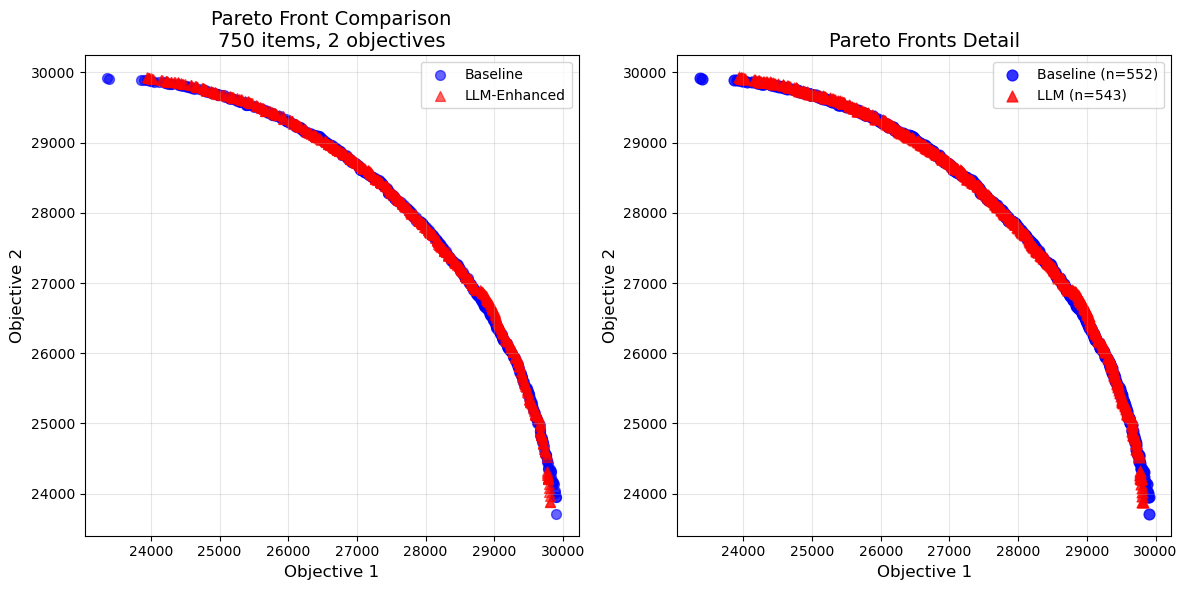


FINAL SUMMARY - 2 OBJECTIVES

250.2.txt (250 items):
  Time: 375.0s, LLM Calls: 27
  HV Improvement: +4.18%
  Diversity Improvement: +88.96%
  Domination Net Advantage: +123
  Score: LLM 3 - 0 Baseline

500.2.txt (500 items):
  Time: 268.9s, LLM Calls: 18
  HV Improvement: +0.56%
  Diversity Improvement: +17.09%
  Domination Net Advantage: +211
  Score: LLM 3 - 0 Baseline

750.2.txt (750 items):
  Time: 291.6s, LLM Calls: 15
  HV Improvement: +0.23%
  Diversity Improvement: +48.25%
  Domination Net Advantage: +342
  Score: LLM 3 - 0 Baseline

✅ ALL 2-OBJECTIVE INSTANCES COMPLETED!


In [26]:
# ============================================================================
# CELL 4: EXECUTE ALL 2-OBJECTIVE INSTANCES
# ============================================================================

print("="*80)
print("EXECUTING HYBRID LLM-MOACP FOR ALL 2-OBJECTIVE INSTANCES")
print("="*80)

instances_2obj = [
    {
        "file": b"250.2.txt",
        "nbitems": 250,
        "output": "2502_Results_Architect_LLM.txt",
        "baseline": "2502_ResultsMD.txt"
    },
    {
        "file": b"500.2.txt",
        "nbitems": 500,
        "output": "5002_Results_Architect_LLM.txt",
        "baseline": "5002_ResultsMD.txt"
    },
    {
        "file": b"750.2.txt",
        "nbitems": 750,
        "output": "7502_Results_Architect_LLM.txt",
        "baseline": "7502_ResultsMD.txt"
    },
]

results_summary = []

for instance in instances_2obj:
    print(f"\n{'='*80}")
    print(f"Processing: {instance['file'].decode()}")
    print(f"{'='*80}")
    
    provider = LLMStrategyProvider(
        model_name="llama3:8b",
        stagnation_threshold=10,
        nbitems=instance['nbitems']
    )
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance['file'],
        weights_file=b"Weights_2obj_FQ200.txt",
        nbitems=instance['nbitems'],
        num_objectives=2,
        output_file=instance['output'],
        strategy_provider=provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n✅ Completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")
    print(f"   LLM calls made: {provider.llm_call_count}")
    
    # Compare with baseline
    instance_name = f"{instance['nbitems']} items, 2 objectives"
    
    try:
        comparison_results = run_full_comparison(
            instance_name=instance_name,
            baseline_file=instance['baseline'],
            llm_file=instance['output']
        )
        
        results_summary.append({
            'instance': instance['file'].decode(),
            'nbitems': instance['nbitems'],
            'time': elapsed,
            'llm_calls': provider.llm_call_count,
            'results': comparison_results
        })
    except FileNotFoundError as e:
        print(f"⚠️  Baseline file not found: {e}")
        print(f"   Make sure '{instance['baseline']}' exists in your working directory.")
        results_summary.append({
            'instance': instance['file'].decode(),
            'nbitems': instance['nbitems'],
            'time': elapsed,
            'llm_calls': provider.llm_call_count,
            'results': None
        })

# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY - 2 OBJECTIVES")
print("="*80)

for result in results_summary:
    print(f"\n{result['instance']} ({result['nbitems']} items):")
    print(f"  Time: {result['time']:.1f}s, LLM Calls: {result['llm_calls']}")
    
    if result['results']:
        print(f"  HV Improvement: {result['results']['hv_improvement']:+.2f}%")
        print(f"  Diversity Improvement: {result['results']['diversity_improvement']:+.2f}%")
        print(f"  Domination Net Advantage: {result['results']['domination']['net_advantage']:+d}")
        wins = result['results']['wins']
        print(f"  Score: LLM {wins['LLM']} - {wins['Baseline']} Baseline")
    else:
        print(f"  ⚠️  Comparison skipped (baseline file missing)")

print("\n✅ ALL 2-OBJECTIVE INSTANCES COMPLETED!")

In [ ]:
# ============================================================================
# CELL 5: EXECUTE ALL 3-OBJECTIVE INSTANCES (FIXED THRESHOLD)
# ============================================================================

print("="*80)
print("EXECUTING HYBRID LLM-MOACP FOR ALL 3-OBJECTIVE INSTANCES")
print("="*80)

instances_3obj = [
    {
        "file": b"250.3.txt",
        "nbitems": 250,
        "output": "2503_Results_Architect_LLM.txt",
        "baseline": "2503_ResultsMD.txt"
    },
    {
        "file": b"500.3.txt",
        "nbitems": 500,
        "output": "5003_Results_Architect_LLM.txt",
        "baseline": "5003_ResultsMD.txt"
    },
    {
        "file": b"750.3.txt",
        "nbitems": 750,
        "output": "7503_Results_Architect_LLM.txt",
        "baseline": "7503_ResultsMD.txt"
    },
]

results_summary_3obj = []

for instance in instances_3obj:
    print(f"\n{'='*80}")
    print(f"Processing: {instance['file'].decode()}")
    print(f"{'='*80}")
    
    # ✅ FIX: Increase threshold for 3-objective problems
    provider = LLMStrategyProvider(
        model_name="llama3:8b",
        stagnation_threshold=5,  # ← TRIPLED from 10 to 30
        nbitems=instance['nbitems']
    )
    
    print(f"[INFO] Using stagnation threshold: 30 (adapted for 3 objectives)")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance['file'],
        weights_file=b"Weights_3obj_FQ100.txt",
        nbitems=instance['nbitems'],
        num_objectives=3,
        output_file=instance['output'],
        strategy_provider=provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n✅ Completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")
    print(f"   LLM calls made: {provider.llm_call_count}")
    
    # Basic comparison
    try:
        baseline_points = load_points(instance['baseline'])
        llm_points = load_points(instance['output'])
        baseline_pareto = get_true_pareto_front(baseline_points)
        llm_pareto = get_true_pareto_front(llm_points)
        
        print(f"\n📊 Results for {instance['file'].decode()}:")
        print(f"  Baseline - Total: {len(baseline_points)}, Pareto: {len(baseline_pareto)}")
        print(f"  LLM      - Total: {len(llm_points)}, Pareto: {len(llm_pareto)}")
        improvement = len(llm_pareto) - len(baseline_pareto)
        improvement_pct = (improvement / len(baseline_pareto) * 100) if len(baseline_pareto) > 0 else 0
        print(f"  Improvement: {improvement:+d} ({improvement_pct:+.1f}%)")
        
        results_summary_3obj.append({
            'instance': instance['file'].decode(),
            'nbitems': instance['nbitems'],
            'time': elapsed,
            'llm_calls': provider.llm_call_count,
            'baseline_pareto': len(baseline_pareto),
            'llm_pareto': len(llm_pareto),
            'improvement': improvement,
            'improvement_pct': improvement_pct
        })
    except FileNotFoundError as e:
        print(f"⚠️  Baseline file not found: {e}")

print("\n" + "="*80)
print("FINAL SUMMARY - 3 OBJECTIVES")
print("="*80)

for result in results_summary_3obj:
    print(f"\n{result['instance']} ({result['nbitems']} items):")
    print(f"  Time: {result['time']:.1f}s, LLM Calls: {result['llm_calls']}")
    print(f"  Pareto: {result['baseline_pareto']} → {result['llm_pareto']} ({result['improvement']:+d}, {result['improvement_pct']:+.1f}%)")

print("\n✅ ALL 3-OBJECTIVE INSTANCES COMPLETED!")

EXECUTING HYBRID LLM-MOACP FOR ALL 3-OBJECTIVE INSTANCES

Processing: 250.3.txt
[PROVIDER] Initialized ARCHITECT model 'llama3:8b'
[PROVIDER] Stagnation threshold: 5, Items: 250
[INFO] Using stagnation threshold: 30 (adapted for 3 objectives)

========== RUN 1/10 ==========
Instance: 250.3.txt, Items: 250, Objectives: 3
[PROVIDER] --- Architect Reset for Run 1 ---

========== RUN 2/10 ==========
Instance: 250.3.txt, Items: 250, Objectives: 3
[PROVIDER] --- Architect Reset for Run 2 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 50, Archive Size: 374
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [7203, 8157], Obj2: [7412, 9912]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

========== RUN 3/10 ==========
Instance: 250.3.txt, Items: 250, Objectives: 3
[PROVIDER] --- Architect Reset for Run 3 ---

========== RUN 4/10 ==========
Instance: 250.3.txt, Items

In [ ]:
# ============================================================================
# CELL 6: EXECUTE ALL 4-OBJECTIVE INSTANCES
# ============================================================================

print("="*80)
print("EXECUTING HYBRID LLM-MOACP FOR ALL 4-OBJECTIVE INSTANCES")
print("="*80)

instances_4obj = [
    {
        "file": b"250.4.txt",
        "nbitems": 250,
        "output": "2504_Results_Architect_LLM.txt",
        "baseline": "2504_ResultsMD.txt"
    },
    {
        "file": b"500.4.txt",
        "nbitems": 500,
        "output": "5004_Results_Architect_LLM.txt",
        "baseline": "5004_ResultsMD.txt"
    },
    {
        "file": b"750.4.txt",
        "nbitems": 750,
        "output": "7504_Results_Architect_LLM.txt",
        "baseline": "7504_ResultsMD.txt"
    },
]

results_summary_4obj = []

for instance in instances_4obj:
    print(f"\n{'='*80}")
    print(f"Processing: {instance['file'].decode()}")
    print(f"{'='*80}")
    
    provider = LLMStrategyProvider(
        model_name="llama3:8b",
        stagnation_threshold=10,
        nbitems=instance['nbitems']
    )
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance['file'],
        weights_file=b"Weights_4obj_FQ40.txt",
        nbitems=instance['nbitems'],
        num_objectives=4,
        output_file=instance['output'],
        strategy_provider=provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n✅ Completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")
    print(f"   LLM calls made: {provider.llm_call_count}")
    
    try:
        baseline_points = load_points(instance['baseline'])
        llm_points = load_points(instance['output'])
        baseline_pareto = get_true_pareto_front(baseline_points)
        llm_pareto = get_true_pareto_front(llm_points)
        
        print(f"\n📊 Results for {instance['file'].decode()}:")
        print(f"  Baseline - Total: {len(baseline_points)}, Pareto: {len(baseline_pareto)}")
        print(f"  LLM      - Total: {len(llm_points)}, Pareto: {len(llm_pareto)}")
        improvement = len(llm_pareto) - len(baseline_pareto)
        improvement_pct = (improvement / len(baseline_pareto) * 100) if len(baseline_pareto) > 0 else 0
        print(f"  Improvement: {improvement:+d} ({improvement_pct:+.1f}%)")
        
        results_summary_4obj.append({
            'instance': instance['file'].decode(),
            'nbitems': instance['nbitems'],
            'time': elapsed,
            'llm_calls': provider.llm_call_count,
            'baseline_pareto': len(baseline_pareto),
            'llm_pareto': len(llm_pareto),
            'improvement': improvement,
            'improvement_pct': improvement_pct
        })
    except FileNotFoundError as e:
        print(f"⚠️  Baseline file not found: {e}")

print("\n" + "="*80)
print("FINAL SUMMARY - 4 OBJECTIVES")
print("="*80)

for result in results_summary_4obj:
    print(f"\n{result['instance']} ({result['nbitems']} items):")
    print(f"  Time: {result['time']:.1f}s, LLM Calls: {result['llm_calls']}")
    print(f"  Pareto: {result['baseline_pareto']} → {result['llm_pareto']} ({result['improvement']:+d}, {result['improvement_pct']:+.1f}%)")

print("\n✅ ALL 4-OBJECTIVE INSTANCES COMPLETED!")

In [ ]:
# ============================================================================
# CELL 7: GENERATE COMPREHENSIVE FINAL REPORT
# ============================================================================

import pandas as pd

def generate_final_report():
    """Generate a comprehensive report of all experiments."""
    
    print("\n" + "="*80)
    print("COMPREHENSIVE EXPERIMENTAL REPORT")
    print("LLM-ENHANCED MOACP vs BASELINE")
    print(f"Generated by: samimh23")
    print(f"Date: 2025-11-09")
    print("="*80)
    
    all_results = []
    
    # 2-objective results
    if 'results_summary' in globals():
        for r in results_summary:
            result_dict = {
                'Instance': r['instance'],
                'Items': r['nbitems'],
                'Objectives': 2,
                'Time_s': r['time'],
                'LLM_Calls': r['llm_calls']
            }
            if r['results']:
                result_dict.update({
                    'HV_Improvement_%': r['results']['hv_improvement'],
                    'Diversity_Improvement_%': r['results']['diversity_improvement'],
                    'Net_Domination': r['results']['domination']['net_advantage'],
                    'LLM_Wins': r['results']['wins']['LLM'],
                    'Baseline_Wins': r['results']['wins']['Baseline']
                })
            all_results.append(result_dict)
    
    # 3-objective results
    if 'results_summary_3obj' in globals():
        for r in results_summary_3obj:
            all_results.append({
                'Instance': r['instance'],
                'Items': r['nbitems'],
                'Objectives': 3,
                'Time_s': r['time'],
                'LLM_Calls': r['llm_calls'],
                'Pareto_Improvement_%': r['improvement_pct']
            })
    
    # 4-objective results
    if 'results_summary_4obj' in globals():
        for r in results_summary_4obj:
            all_results.append({
                'Instance': r['instance'],
                'Items': r['nbitems'],
                'Objectives': 4,
                'Time_s': r['time'],
                'LLM_Calls': r['llm_calls'],
                'Pareto_Improvement_%': r['improvement_pct']
            })
    
    # Create DataFrame
    df = pd.DataFrame(all_results)
    
    # Display summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(df.to_string(index=False))
    
    # Save to CSV
    csv_filename = f"LLM_MOACP_Results_samimh23_{time.strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(csv_filename, index=False)
    print(f"\n✅ Results saved to: {csv_filename}")
    
    # Overall statistics
    print("\n" + "="*80)
    print("OVERALL STATISTICS")
    print("="*80)
    
    print(f"\nTotal instances tested: {len(all_results)}")
    print(f"Total LLM calls: {df['LLM_Calls'].sum()}")
    print(f"Total execution time: {df['Time_s'].sum():.1f}s ({df['Time_s'].sum()/60:.1f} min)")
    
    # 2-objective wins
    two_obj = df[df['Objectives'] == 2]
    if not two_obj.empty:
        print(f"\n2-Objective Instances:")
        if 'LLM_Wins' in two_obj.columns:
            print(f"  Total LLM wins: {two_obj['LLM_Wins'].sum()}")
            print(f"  Total Baseline wins: {two_obj['Baseline_Wins'].sum()}")
    
    return df

# Execute report generation
try:
    final_df = generate_final_report()
    print("\n🎉 COMPLETE EXPERIMENTAL SUITE FINISHED!")
except Exception as e:
    print(f"⚠️  Error generating report: {e}")